# k-Nearest Neighbors Part 1: Brute-Force KNN from Scratch

## Goal

KNN is different from linear regression and logistic regression.

Linear and logistic regression are **parametric models**:

```text
Training data -> learn parameters w -> use w for prediction
```

After training, the model only needs the learned weights.

KNN is **non-parametric**, **lazy**, and **instance-based**:

```text
Training data -> store the data -> compare new points to stored examples
```

There is no gradient descent.

There is no learned weight vector.

There is no closed-form solution.

The training set itself is the model.

---

## Main Idea

To classify a new query point `z`:

1. Compute the distance from `z` to every training point.
2. Find the `k` closest training points.
3. Look at their labels.
4. Predict the majority label.

---

## Euclidean Distance

For a query point `z` and a training point `x`, the Euclidean distance is:

$$
d(z, x) = \sqrt{\sum_{j=1}^{d}(z_j - x_j)^2}
$$

where:

- `z` is the query point
- `x` is a training point
- `d` is the number of features

For 2D data:

$$
d(z, x) = \sqrt{(z_1 - x_1)^2 + (z_2 - x_2)^2}
$$

---

## KNN Prediction Rule

Let `N_k(z)` be the set of the `k` closest training points to query point `z`.

Then KNN predicts:

$$
\hat{y} = \text{majority label among the k nearest neighbors}
$$

So if `k = 5` and the nearest labels are:

```python
[1, 1, 0, 1, 0]
```

then KNN predicts:

```python
1
```

because class `1` appears most often.

---

## Why KNN Is Called Lazy

KNN has almost no training step.

The `fit` step just stores:

```python
X_train
y_train
```

All the computation happens during prediction.

This is the opposite of logistic regression, where training is expensive but prediction is cheap.

In [78]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

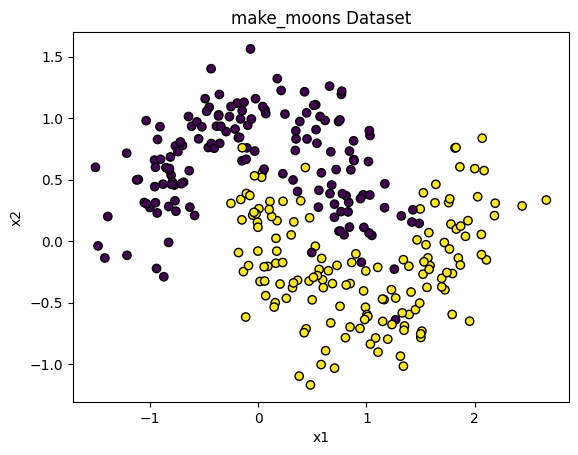

In [79]:
# generate nonlinear 2D classification data 
X, y = make_moons(n_samples = 300, noise = 0.25, random_state= 0)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size= 0.25, 
    random_state = 0
)

plt.scatter(X[:, 0], X[:, 1], c = y, edgecolors= "k")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("make_moons Dataset")
plt.show()

## Brute-force KNN from scratch

A simple version of KNN using the euclidean distance 

In [80]:
class KNNFromScratch:
    def __init__(self, k = 5):
        self.k = k
        
    def fit(self, X_train, y_train):
        # KNN has no real training step. 
        # It just stores the training data
        self.X_train = X_train
        self.y_train = y_train 
        
    def predict_one(self, z):
        # Compute distance from z to every training point 
        distances = np.sqrt(np.sum((self.X_train - z) ** 2, axis = 1))
        
        # get indices of k closest points 
        nearest_indices = np.argsort(distances)[:self.k]
        
        # get labels of k closest points 
        nearest_labels = self.y_train[nearest_indices]
        
        # majority vote 
        counts = np.bincount(nearest_labels)
        prediction = np.argmax(counts)
        
        return prediction
    
    def predict(self, Z):
        predictions = []
        
        for z in Z:
            pred = self.predict_one(z)
            predictions.append(pred)
        return np.array(predictions)

## Train and Test KNN

"Fit" only stores the data. 

In [81]:
knn = KNNFromScratch(k = 5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = np.mean(y_pred == y_test)

print("Test Accuracy: ", accuracy)

Test Accuracy:  0.96


## Plot Decision Boundary

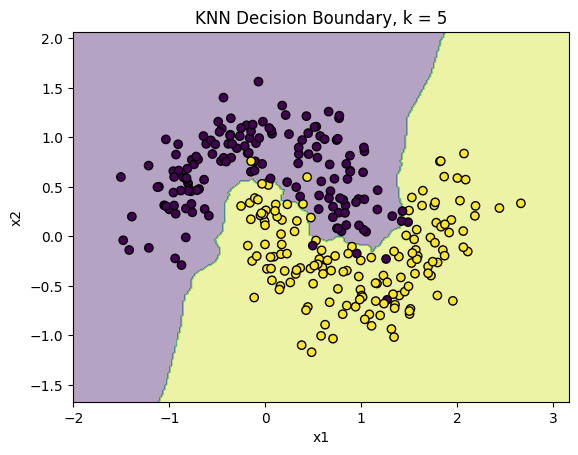

In [82]:
def plot_decision_boundary(model, X, y, title):
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )

    grid = np.c_[xx1.ravel(), xx2.ravel()]

    grid_pred = model.predict(grid)
    grid_pred = grid_pred.reshape(xx1.shape)

    plt.contourf(xx1, xx2, grid_pred, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()
    
plot_decision_boundary(
    knn,
    X,
    y,
    title="KNN Decision Boundary, k = 5"
)

Here we can see a curved, flexible decision boundary. The key difference from logistic regression without feature maps: KNN can naturally adapt to local structure. 

## Vectorized Distance Computation

The loop version works, but is slow. We can compute all distances at once. 

For query matrix Z and training matrix X, the squared distance is:

$$
|Z|^2 + |X|^2 - 2ZX^\top
$$

This gives a matrix where entry (i, j) is the squared distance between query points Z[i] and training point X[j]. 

In [83]:
def pairwise_squared_distances(Z, X):
    Z_norms = np.sum(Z ** 2, axis = 1, keepdims = True)
    X_norms = np.sum(X ** 2, axis = 1)
    
    distances_squared = Z_norms + X_norms - 2 * Z @ X.T
    
    # numerical safety: avoid tiny negative values from floating-point error
    distances_squared = np.maximum(distances_squared, 0)
    
    return distances_squared

D2 = pairwise_squared_distances(X_test, X_train)

print("Distance matrix shape:", D2.shape)

Distance matrix shape: (75, 225)


## Vectorized KNN Class

In [84]:
class KNNVectorized:
    def __init__(self, k = 5):
        self.k = k
        
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        
    def predict(self, Z):
        # compute all squared distances at once
        distances_squared = pairwise_squared_distances(Z, self.X_train)
        
        # for each query row, get indices of k nearest training points
        nearest_indices = np.argsort(distances_squared, axis = 1)[:, :self.k]
        
        # get labels of nearest neighbors 
        nearest_labels = self.y_train[nearest_indices]
        
        # majority vote for each query point
        predictions = []
        
        for labels in nearest_labels:
            counts = np.bincount(labels)
            prediction = np.argmax(counts)
            predictions.append(prediction)
            
        return np.array(predictions)

### Running it

In [85]:
knn_vec = KNNVectorized(k = 5)

knn_vec.fit(X_train, y_train)

y_pred_vec = knn_vec.predict(X_test)

accuracy_vec = np.mean(y_pred_vec == y_test)

print("Vectorized KNN accuracy: ", accuracy_vec)

Vectorized KNN accuracy:  0.96


## Compare Against SKlearn

In [86]:
sklearn_knn = KNeighborsClassifier(n_neighbors=5)

sklearn_knn.fit(X_train, y_train)

y_pred_sklearn = sklearn_knn.predict(X_test)

accuracy_sklearn = np.mean(y_pred_sklearn == y_test)

print("Scratch KNN accuracy:", accuracy_vec)
print("Sklearn KNN accuracy:", accuracy_sklearn)

print("Predictions match sklearn:", np.array_equal(y_pred_vec, y_pred_sklearn))

Scratch KNN accuracy: 0.96
Sklearn KNN accuracy: 0.96
Predictions match sklearn: True


## Time Loop vs Vectorized Version

In [87]:
import time

# loop version
start = time.time()
y_pred_loop = knn.predict(X_test)
loop_time = time.time() - start 

# vectorized version
start = time.time()
y_pred_vec = knn_vec.predict(X_test)
vectorized_time = time.time() - start 

print("Loop Time: ", loop_time)
print("Vectorized Time: ", vectorized_time)
print("Predictions Match: ", np.array_equal(y_pred_loop, y_pred_vec))

Loop Time:  0.0017130374908447266
Vectorized Time:  0.0007140636444091797
Predictions Match:  True


# k-Nearest Neighbors Part 2: Choosing k as the Bias-Variance Knob

## Goal

The main hyperparameter in KNN is `k`, the number of neighbors used to make a prediction.

Changing `k` changes how flexible the decision boundary is.

Small `k` gives a very flexible model.

Large `k` gives a smoother, simpler model.

So `k` controls the **bias-variance tradeoff**.

---

## What Happens When k Is Small?

When:

```python
k = 1
```

the model predicts using only the single closest training point.

This means the model can memorize the training data.

For classification, `k = 1` usually gives very low training error, sometimes even zero training error.

But the decision boundary can become jagged and sensitive to noise.

This is high variance.

```text
small k -> flexible boundary -> low bias -> high variance
```

---

## What Happens When k Is Large?

When `k` is large, each prediction averages over many nearby points.

The boundary becomes smoother.

But if `k` is too large, the model becomes too simple.

At the extreme:

```python
k = N
```

where `N` is the number of training points, every prediction uses the whole training set.

Then the model just predicts the majority class everywhere.

This is high bias.

```text
large k -> smooth boundary -> high bias -> low variance
```

---

## Bias-Variance Tradeoff

KNN has one main complexity knob:

```python
k
```

Small `k` means high model complexity.

Large `k` means low model complexity.

The effective complexity roughly behaves like:

```text
complexity ≈ N / k
```

So:

```text
k = 1       -> maximum complexity
k large     -> low complexity
k = N       -> majority-class classifier
```

---

## Why Use Odd k?

For binary classification, we usually choose an odd value of `k`.

For example:

```python
k = 1, 3, 5, 7, 9
```

This helps avoid tie votes.

If `k = 4`, the nearest labels could be:

```python
[0, 0, 1, 1]
```

That creates a tie.

Odd `k` makes ties less likely in binary classification.

---

## Main Idea

Choosing `k` is choosing between overfitting and underfitting.

```text
k too small -> overfitting
k too large -> underfitting
k just right -> good generalization
```

We pick `k` using validation data or cross-validation.

In [88]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

## Make Data

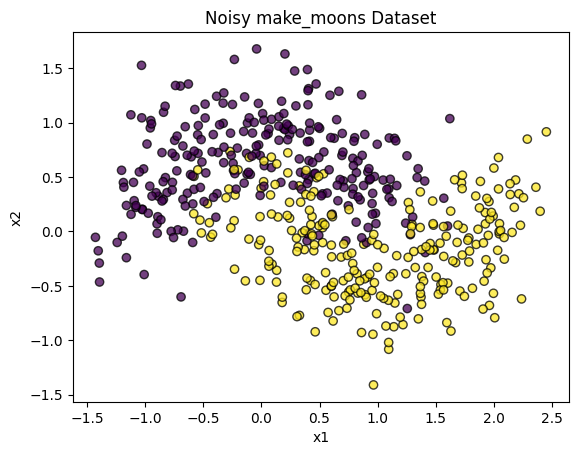

In [89]:
np.random.seed(0)

X, y = make_moons(
    n_samples=500,
    noise=0.3,
    random_state=0
)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.75)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Noisy make_moons Dataset")
plt.show()

## Decision Boundary Helper 

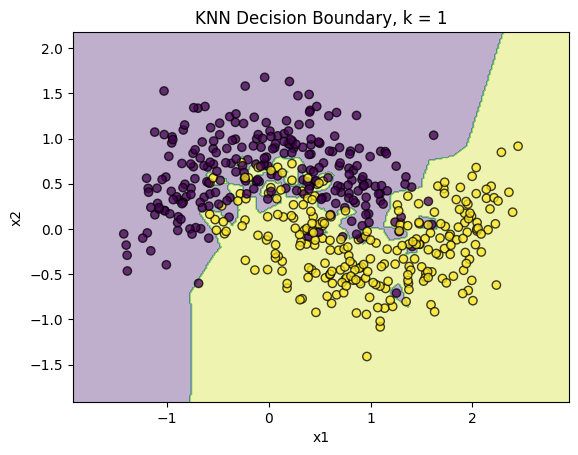

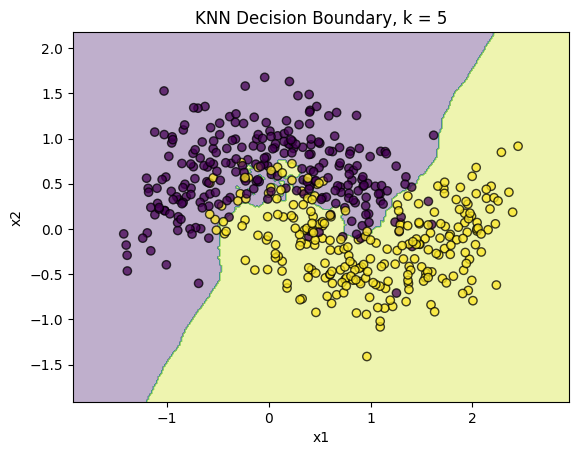

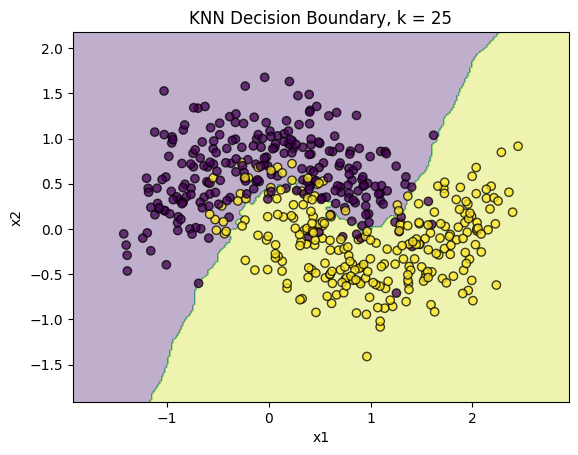

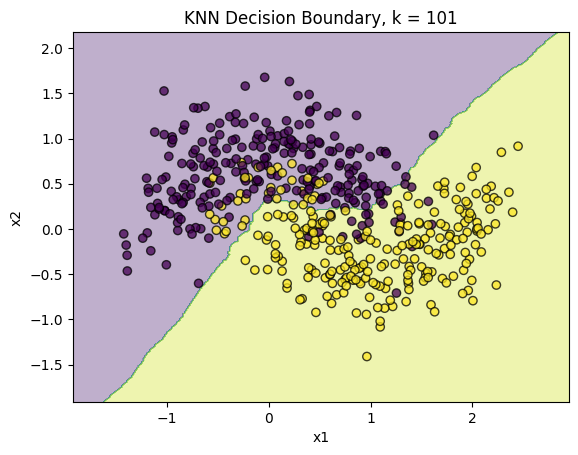

In [90]:
def plot_knn_boundary(k, X_train, y_train, X, y):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )

    grid = np.c_[xx1.ravel(), xx2.ravel()]
    grid_pred = model.predict(grid).reshape(xx1.shape)

    plt.contourf(xx1, xx2, grid_pred, alpha=0.35)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.75)

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"KNN Decision Boundary, k = {k}")
    plt.show()
    
k_values_to_plot = [1, 5, 25, 101]

for k in k_values_to_plot:
    plot_knn_boundary(k, X_train, y_train, X, y)

**Note**

k = 1:
- very jagged boundary
- memorizes individual noisy points
- high variance

k = 5:
- still flexible
- usually a good balance

k = 25:
- smoother boundary
- less sensitive to noise

k = 101:
- very smooth boundary
- may underfit

## Training and Validation error vs k

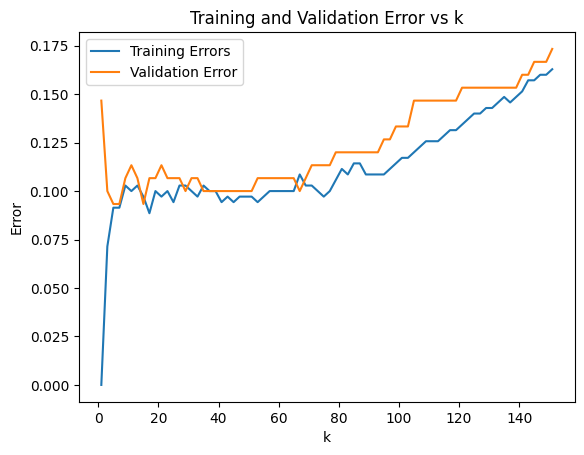

In [91]:
k_values = list(range(1, 152, 2))

train_errors    = []
val_errors      = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    train_accuracy  = model.score(X_train, y_train)
    val_accuracy    = model.score(X_val, y_val)
    
    train_errors.append(1 - train_accuracy)
    val_errors.append(1 - val_accuracy)
    
plt.plot(k_values, train_errors, label = "Training Errors")
plt.plot(k_values, val_errors, label = "Validation Error")

plt.xlabel("k")
plt.ylabel("Error")
plt.title("Training and Validation Error vs k")
plt.legend()
plt.show()

We can note: 

- training error usually increases as k increases
- validation error often decreases first, then increases

This showcases the bias-variance tradeoff. 

Small k overfits. Large k underfits


## Pick the best k from validation error 

In [92]:
best_index      = np.argmin(val_errors)
best_k          = k_values[best_index]
best_val_error  = val_errors[best_index]

print("Best k: ", best_k)
print("Best Validation Error: ", best_val_error)
print("Best Validation Accuracy: ", 1 - best_val_error)

Best k:  5
Best Validation Error:  0.09333333333333338
Best Validation Accuracy:  0.9066666666666666


## Cross-Validation for k

Instead of using one validation split, we can use cross-validation

In [93]:
cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_scores.append(scores.mean())

best_cv_index = np.argmax(cv_scores)
best_cv_k = k_values[best_cv_index]

print("Best k by cross-validation:", best_cv_k)
print("Best CV accuracy:", cv_scores[best_cv_index])

Best k by cross-validation: 37
Best CV accuracy: 0.9057142857142857


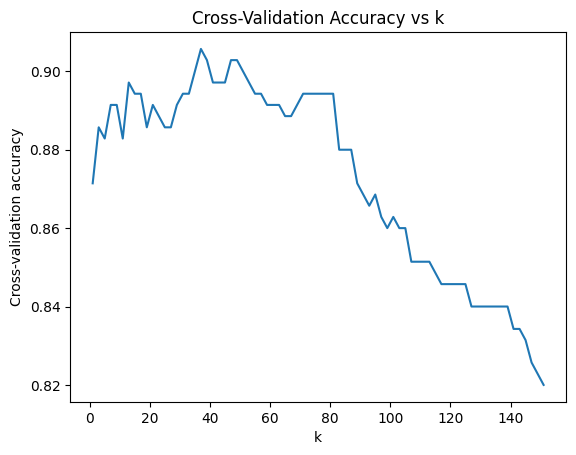

In [94]:
plt.plot(k_values, cv_scores)

plt.xlabel("k")
plt.ylabel("Cross-validation accuracy")
plt.title("Cross-Validation Accuracy vs k")
plt.show()

## Final Model with best k

In [95]:
final_knn = KNeighborsClassifier(n_neighbors=best_cv_k)
final_knn.fit(X_train, y_train)

train_accuracy = final_knn.score(X_train, y_train)
val_accuracy = final_knn.score(X_val, y_val)

print("Final k:", best_cv_k)
print("Training accuracy:", train_accuracy)
print("Validation accuracy:", val_accuracy)

Final k: 37
Training accuracy: 0.9
Validation accuracy: 0.9


### Plot the final boundary 



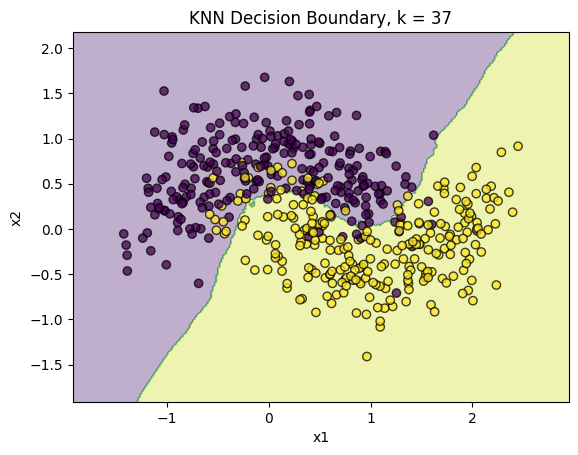

In [96]:
plot_knn_boundary(best_cv_k, X_train, y_train, X, y)

# k-Nearest Neighbors Part 3: Distance Metrics and Feature Scaling

## Goal

KNN makes predictions by comparing distances between points.

That means the distance function is basically the model.

Unlike logistic regression, KNN does not learn weights that tell it which features matter. Instead, the scale of each feature directly affects the distance calculation.

If one feature has much larger values than another feature, it can dominate the distance.

---

## Euclidean Distance

The default KNN distance is usually Euclidean distance:

$$
d(z, x) = \sqrt{\sum_{j=1}^{d}(z_j - x_j)^2}
$$

For two features:

$$
d(z, x) = \sqrt{(z_1 - x_1)^2 + (z_2 - x_2)^2}
$$

If one feature ranges from `0` to `1`, and another feature ranges from `0` to `10000`, then the second feature dominates the distance.

So KNN may almost completely ignore the small-scale feature.

---

## Feature Scaling Problem

Suppose:

```python
x1 in [0, 1]
x2 in [0, 10000]
```

Then a small change in `x2` can overwhelm a large meaningful change in `x1`.

That means KNN will think points are close mainly based on `x2`.

This is one of the most common KNN mistakes.

---

## Standardization

To fix this, we standardize each feature:

$$
x_{standardized} = \frac{x - \hat{\mu}}{\hat{\sigma}}
$$

where:

- `mu_hat` is the training feature mean
- `sigma_hat` is the training feature standard deviation

Important rule:

```text
Compute mean and std from the training set only.
Then apply those same values to train and test data.
```

This avoids data leakage.

---

## Distance Metrics

KNN can use different distance metrics.

### Manhattan Distance

Manhattan distance, also called L1 distance, is:

$$
d(z, x) = \sum_{j=1}^{d}|z_j - x_j|
$$

This measures distance as movement along coordinate axes.

It can be more robust when one dimension has a large difference.

---

### Minkowski Distance

Minkowski distance generalizes L1 and L2 distance:

$$
d(z, x) = \left(\sum_{j=1}^{d}|z_j - x_j|^p\right)^{1/p}
$$

Special cases:

```text
p = 1 -> Manhattan distance
p = 2 -> Euclidean distance
```

---

### Cosine Distance

Cosine distance measures direction rather than magnitude:

$$
d(z, x) = 1 - \frac{z \cdot x}{\|z\|\|x\|}
$$

Cosine distance is useful when the direction of a vector matters more than its size.

This is common for text embeddings, document vectors, and recommendation systems.

---

## Main Idea

KNN has no learned weights.

So the distance metric and feature scaling carry most of the modeling.

```text
Bad scaling -> bad distances -> bad neighbors -> bad predictions
```

For KNN, standardization is not optional. It is usually necessary.